# RAVDESS and Actor 25 label analysis

This notebook counts emotion and gender labels from the RAVDESS filenames. It shows the RAVDESS data, my voice recordings, and the combined data with simple bar charts.

In [1]:
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt

screenshot_dir = Path("screenshots")
screenshot_dir.mkdir(exist_ok=True)

emotions = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
}
emotion_order = list(emotions.values())
gender_order = ["male", "female"]

def find_folder(options, name):
    for folder in options:
        if folder.is_dir():
            return folder
    raise FileNotFoundError(f"Could not find {name}. Follow the setup instructions in the README.")

ravdess_dir = find_folder([Path("data/RAVDESS"), Path("work/RAVDESS"), Path("RAVDESS")], "RAVDESS")
voice_dir = find_folder([Path("data/Actor_25"), Path("work/Actor_25_pcm"), Path("work/Actor_25"), Path("Actor_25")], "Actor 25 recordings")
print("RAVDESS folder:", ravdess_dir)
print("Actor 25 folder:", voice_dir)

def read_labels(folder):
    rows = []
    for path in sorted(folder.rglob("*.wav")):
        parts = path.stem.split("-")
        if len(parts) != 7 or parts[0] != "03" or parts[1] != "01":
            continue
        actor = int(parts[6])
        rows.append({"emotion": emotions[parts[2]], "gender": "male" if actor == 25 or actor % 2 == 1 else "female"})
    return rows

ravdess = read_labels(ravdess_dir)
my_voice = read_labels(voice_dir)
combined = ravdess + my_voice

def show_counts(name, rows):
    emotion_counts = Counter(row["emotion"] for row in rows)
    gender_counts = Counter(row["gender"] for row in rows)
    print(f"{name}: {len(rows)} recordings")
    print("Emotion counts:", {emotion: emotion_counts[emotion] for emotion in emotion_order})
    print("Gender counts:", {gender: gender_counts[gender] for gender in gender_order})

show_counts("RAVDESS only", ravdess)
show_counts("My voice only", my_voice)
show_counts("Combined", combined)

RAVDESS folder: work/RAVDESS
Actor 25 folder: work/Actor_25_pcm
RAVDESS only: 1440 recordings
Emotion counts: {'neutral': 96, 'calm': 192, 'happy': 192, 'sad': 192, 'angry': 192, 'fearful': 192, 'disgust': 192, 'surprised': 192}
Gender counts: {'male': 720, 'female': 720}
My voice only: 60 recordings
Emotion counts: {'neutral': 4, 'calm': 8, 'happy': 8, 'sad': 8, 'angry': 8, 'fearful': 8, 'disgust': 8, 'surprised': 8}
Gender counts: {'male': 60, 'female': 0}
Combined: 1500 recordings
Emotion counts: {'neutral': 100, 'calm': 200, 'happy': 200, 'sad': 200, 'angry': 200, 'fearful': 200, 'disgust': 200, 'surprised': 200}
Gender counts: {'male': 780, 'female': 720}


## RAVDESS only

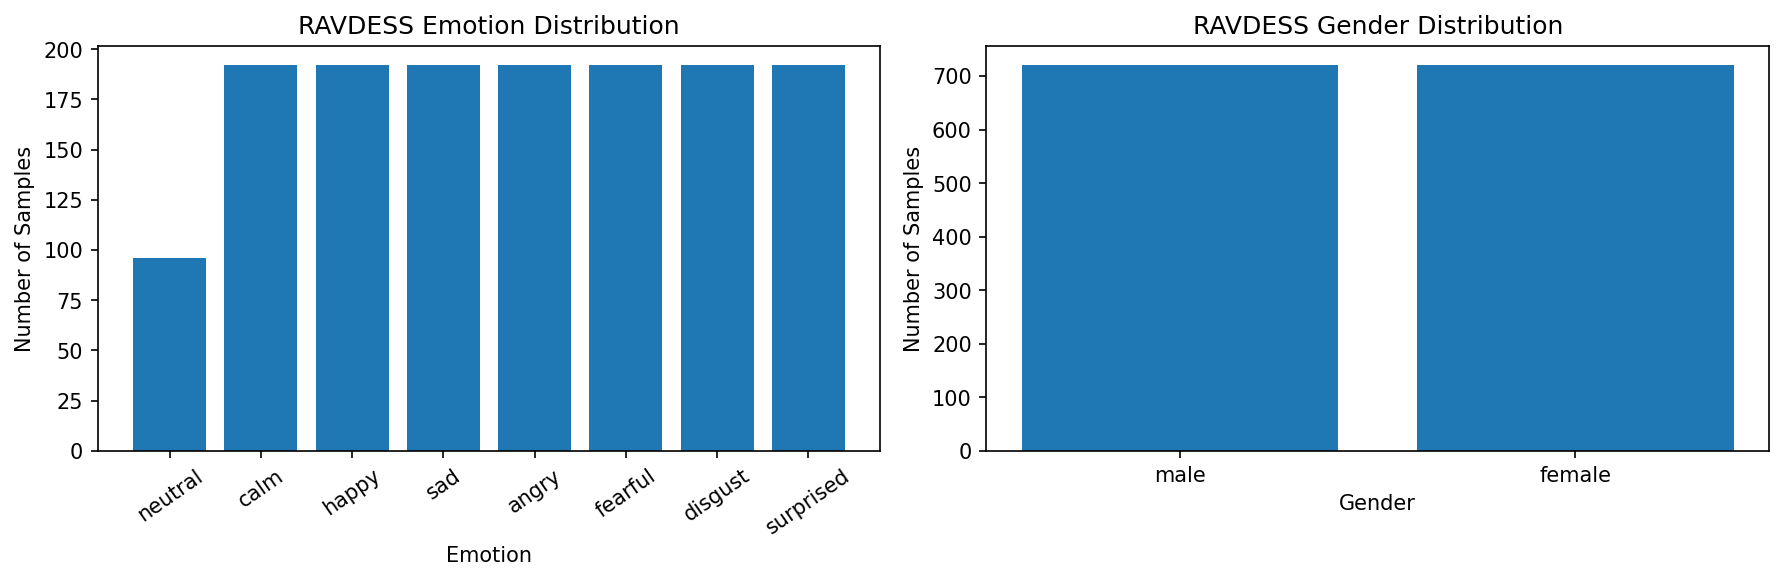

In [2]:
emotion_counts = Counter(row["emotion"] for row in ravdess)
gender_counts = Counter(row["gender"] for row in ravdess)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(emotion_order, [emotion_counts[e] for e in emotion_order])
axes[0].set_title("RAVDESS Emotion Distribution")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis="x", rotation=35)
axes[1].bar(gender_order, [gender_counts[g] for g in gender_order])
axes[1].set_title("RAVDESS Gender Distribution")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Number of Samples")
plt.tight_layout()
fig.savefig(screenshot_dir / "ravdess_results.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## My voice only

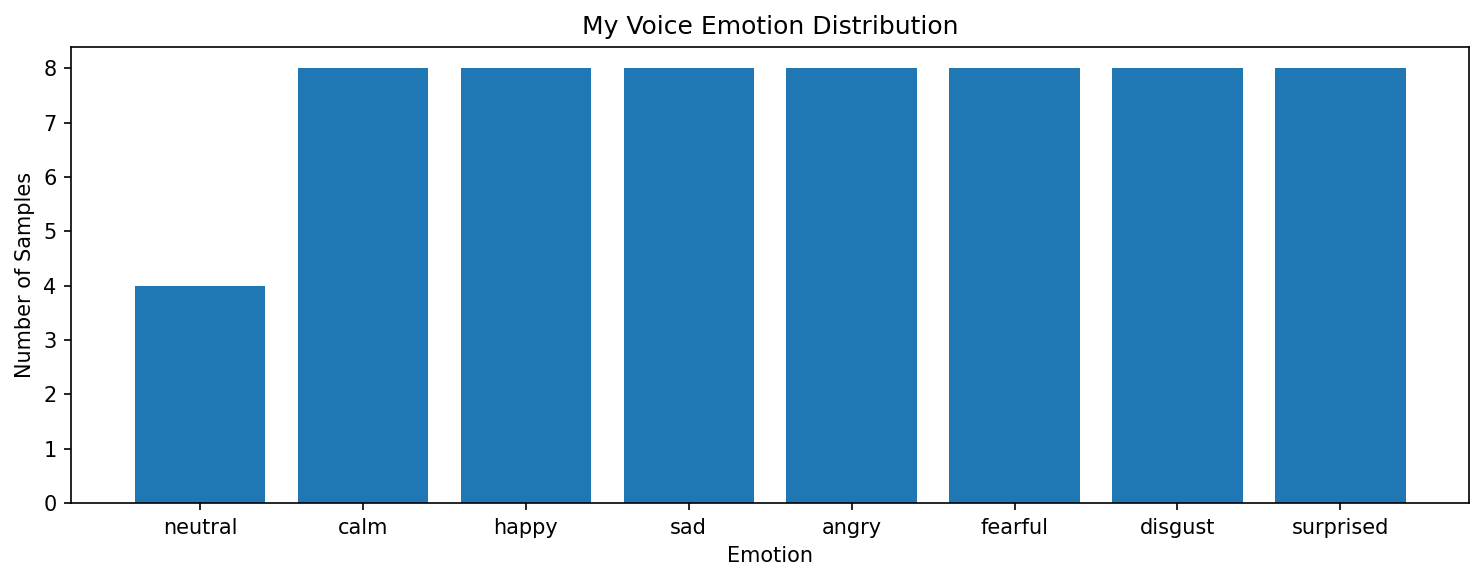

In [3]:
voice_counts = Counter(row["emotion"] for row in my_voice)
plt.figure(figsize=(10, 4))
plt.bar(emotion_order, [voice_counts[e] for e in emotion_order])
plt.title("My Voice Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig(screenshot_dir / "my_voice_results.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

## Combined data

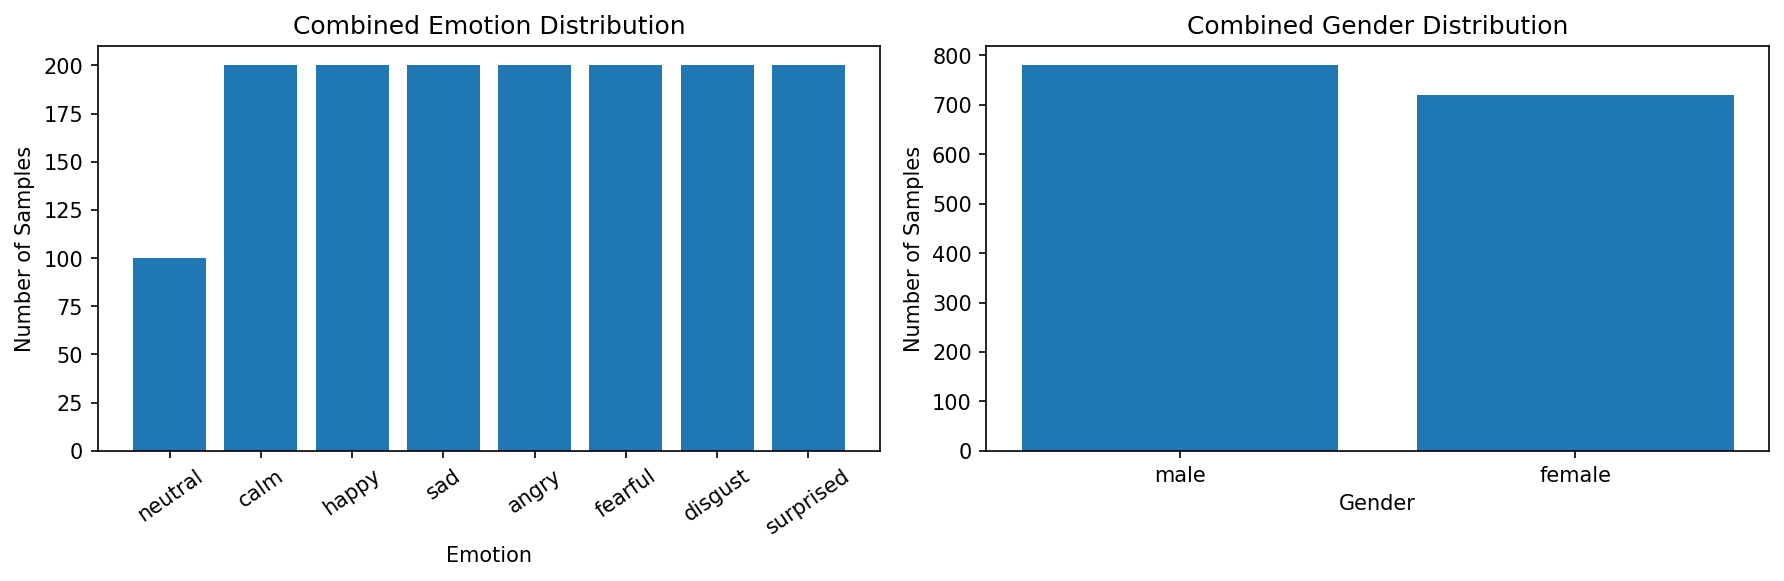

In [4]:
combined_emotions = Counter(row["emotion"] for row in combined)
combined_genders = Counter(row["gender"] for row in combined)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(emotion_order, [combined_emotions[e] for e in emotion_order])
axes[0].set_title("Combined Emotion Distribution")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis="x", rotation=35)
axes[1].bar(gender_order, [combined_genders[g] for g in gender_order])
axes[1].set_title("Combined Gender Distribution")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Number of Samples")
plt.tight_layout()
fig.savefig(screenshot_dir / "combined_results.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## Notes

RAVDESS has 1,440 recordings from 24 actors. Its gender counts are equal, with 720 male and 720 female recordings. It has 96 neutral recordings and 192 for each other emotion. My voice folder has 60 recordings: 4 neutral and 8 for each other emotion. All 60 are labelled male because they are from Actor 25.

The combined dataset has 1,500 recordings: 100 neutral and 200 for each other emotion. It has 780 male and 720 female recordings (52% and 48%). The recording counts are close to balanced by gender, but Actor 25 is one speaker, so these extra recordings do not represent additional speakers.